# State/Quarter Clustering

Quarter chi-square test: chi2=477.13, p=0.000000, dof=3
State chi-square test:   chi2=7465.28, p=0.000000, dof=50
Coefficient of variation across states: 0.3338
Q1 to Q4 drift: 0.72 percentage points


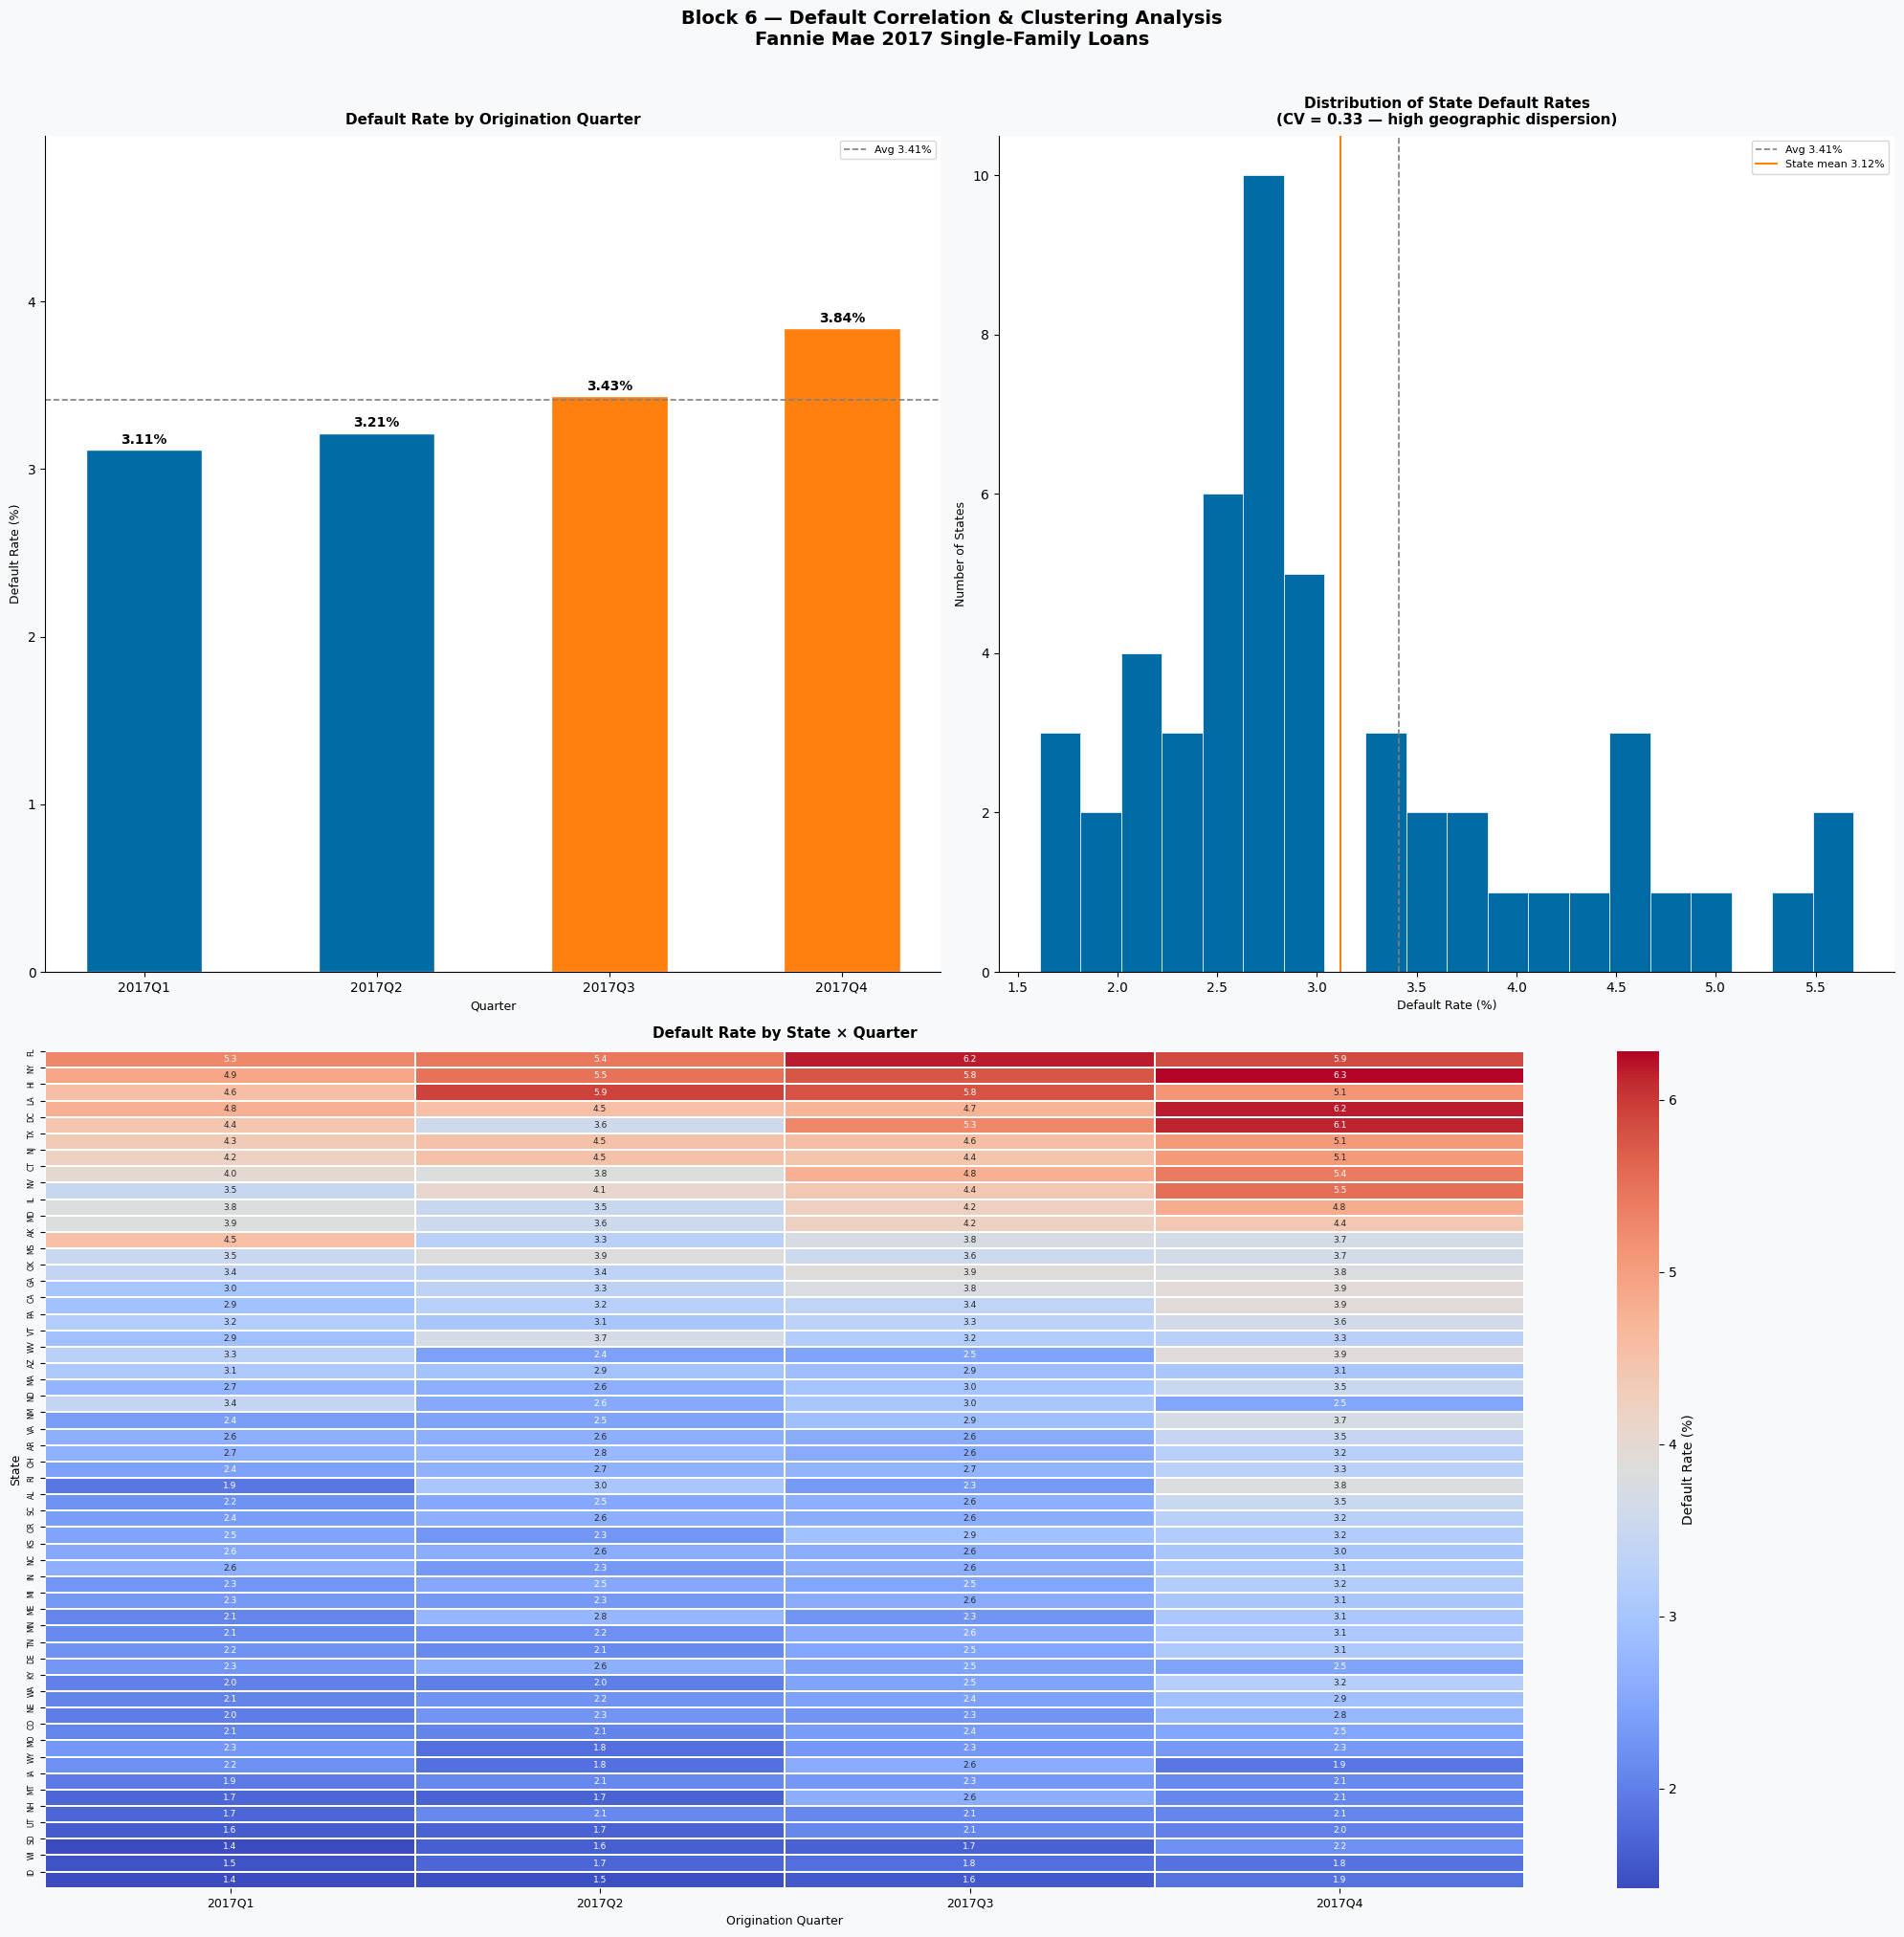

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('tableau-colorblind10')
prop_cycle = plt.rcParams['axes.prop_cycle']
palette = [c['color'] for c in prop_cycle]

df = pd.read_parquet('../data/processed/fannie_2017_clean.parquet')
df['default_flag'] = df['default_flag'].astype(float)

# drop territories
exclude = ['VI', 'PR', 'GU']
df = df[~df['STATE'].isin(exclude)]

BAR_COLOR  = palette[0]
HIGH_COLOR = palette[1]
AVG_RATE   = 3.41

contingency_quarter = pd.crosstab(df['orig_quarter'], df['default_flag'])
chi2_q, p_q, dof_q, _ = stats.chi2_contingency(contingency_quarter)
print(f'Quarter chi-square test: chi2={chi2_q:.2f}, p={p_q:.6f}, dof={dof_q}')

contingency_state = pd.crosstab(df['STATE'], df['default_flag'])
chi2_s, p_s, dof_s, _ = stats.chi2_contingency(contingency_state)
print(f'State chi-square test:   chi2={chi2_s:.2f}, p={p_s:.6f}, dof={dof_s}')

state_rates = df.groupby('STATE')['default_flag'].mean() * 100
cv = state_rates.std() / state_rates.mean()
print(f'Coefficient of variation across states: {cv:.4f}')

q_rates = df.groupby('orig_quarter')['default_flag'].mean()
print(f'Q1 to Q4 drift: {(q_rates.iloc[-1] - q_rates.iloc[0])*100:.2f} percentage points')

fig = plt.figure(figsize=(20, 20))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle(
    'Block 6 — Default Correlation & Clustering Analysis\n'
    'Fannie Mae 2017 Single-Family Loans',
    fontsize=14, fontweight='bold', y=1.01
)

ax1 = fig.add_subplot(2, 2, 1)
q_stats = df.groupby('orig_quarter')['default_flag'].agg(['mean', 'count']).reset_index()
q_stats['pct'] = q_stats['mean'] * 100
colors = [HIGH_COLOR if v > AVG_RATE else BAR_COLOR for v in q_stats['pct']]
bars = ax1.bar(q_stats['orig_quarter'], q_stats['pct'], color=colors,
               edgecolor='white', width=0.5)
ax1.axhline(y=AVG_RATE, color='gray', linestyle='--',
            linewidth=1.2, label=f'Avg {AVG_RATE}%')
for bar, row in zip(bars, q_stats.itertuples()):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f'{row.pct:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Default Rate by Origination Quarter', fontsize=11, fontweight='bold', pad=8)
ax1.set_ylabel('Default Rate (%)', fontsize=9)
ax1.set_xlabel('Quarter', fontsize=9)
ax1.set_ylim(0, max(q_stats['pct']) * 1.3)
ax1.legend(fontsize=8)
ax1.set_facecolor('white')
ax1.spines[['top', 'right']].set_visible(False)

ax2 = fig.add_subplot(2, 2, 2)
ax2.hist(state_rates, bins=20, color=BAR_COLOR, edgecolor='white', linewidth=0.5)
ax2.axvline(x=AVG_RATE, color='gray', linestyle='--',
            linewidth=1.2, label=f'Avg {AVG_RATE}%')
ax2.axvline(x=state_rates.mean(), color=HIGH_COLOR, linestyle='-',
            linewidth=1.5, label=f'State mean {state_rates.mean():.2f}%')
ax2.set_title(f'Distribution of State Default Rates\n(CV = {cv:.2f} — high geographic dispersion)',
              fontsize=11, fontweight='bold', pad=8)
ax2.set_xlabel('Default Rate (%)', fontsize=9)
ax2.set_ylabel('Number of States', fontsize=9)
ax2.legend(fontsize=8)
ax2.set_facecolor('white')
ax2.spines[['top', 'right']].set_visible(False)

ax3 = fig.add_subplot(2, 1, 2)
pivot = df.groupby(['STATE', 'orig_quarter'])['default_flag'].mean().unstack() * 100
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='coolwarm',
    linewidths=0.3, linecolor='white',
    annot_kws={'size': 6.5}, ax=ax3,
    cbar_kws={'label': 'Default Rate (%)'}
)
ax3.set_title('Default Rate by State × Quarter',
              fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Origination Quarter', fontsize=9)
ax3.set_ylabel('State', fontsize=9)
ax3.set_yticks(range(len(pivot)))
ax3.set_yticklabels(pivot.index, fontsize=5.5)
ax3.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

**Observations**

Quarter Chart
- Q1 and Q2 sit below the 3.41% average, early 2017 originations carried lower risk
- Q3 and Q4 cross above the average, with Q4 reaching 3.84% a 0.73 percentage point drift across the year
- The trend is monotonically increasing, each quarter is riskier than the last

State Distribution
- The distribution is right-skewed, most states cluster between 2.5–3.5% but a handful of high-risk states pull the tail out to 5.5%+
- The state mean (3.12%) sits below the portfolio average (3.41%) confirming that a small number of high-volume, high-risk states like FL and NY are pulling the portfolio average up
- CV of 0.33 confirms high geographic dispersion, states are not interchangeable in the simulation

State × Quarter Heatmap
- The top 8–10 states show deep red across all four quarters, persistent high-risk, not seasonal noise
- The bottom third of states remain consistently blue across all quarters, stable low-risk tier suitable for LP diversification anchoring
- Several mid-tier states show Q4 darkening, risk escalation concentrated in the back half of 2017